# Laboratorio 8 — Simulación Monte Carlo: Álbum de Figuritas
**MM3014 · Teoría de Probabilidades | Universidad del Valle de Guatemala (UVG)**  
**Integrantes:**  
*  **Javier Alvarado** - Carné 24546  
*  **Hugo Méndez** - Carné 241265  

---

##  Etapa 3 — Incorporación del Presupuesto y Costo

En esta etapa incorporamos una restricción económica al modelo: cada sobre cuesta **Q 9.50** y el coleccionista dispone de un **presupuesto total de Q 1 000**.  
La simulación determina si es posible completar el álbum con ese presupuesto y qué estrategia de compra maximiza esa probabilidad.

**Parámetros:**

| Parámetro | Valor | Descripción |
|:---:|:---:|:---|
| $N$ | 100 | Estampas distintas en el álbum |
| $S$ | 7 | Estampas por sobre (únicas dentro del sobre) |
| $R$ | 10 000 | Simulaciones independientes |
| Precio | Q 9.50 | Precio de un sobre suelto |
| Presupuesto | Q 1 000 | Presupuesto total del coleccionista |
| Semilla | 2026 | Semilla para reproducibilidad |

##  Importaciones y Parámetros

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Parámetros
N      = 100        # estampas distintas
S      = 7          # estampas por sobre (únicas dentro del sobre)
R      = 10_000     # simulaciones
PRICE  = 9.50       # precio por sobre (Q)
BUDGET = 1_000.0    # presupuesto total (Q)
SEED   = 2026

# Función auxiliar: P(completar) con n_packs sobres fijos
def simulate_packs(n_packs, seed=None):
    """Compra n_packs sobres por simulación.
    Retorna la proporción de simulaciones en que se completó el álbum."""
    if seed is not None:
        np.random.seed(seed)
    completed = 0
    for _ in range(R):
        collected = np.zeros(N, dtype=bool)
        for _ in range(n_packs):
            pack = np.random.choice(N, S, replace=False)
            collected[pack] = True
        if collected.all():
            completed += 1
    return completed / R

print(f"Parámetros cargados. Máximo de sobres con Q{BUDGET:.0f}: {int(BUDGET // PRICE)}")

Parámetros cargados. Máximo de sobres con Q1000: 105


## Simulación con Restricción de Presupuesto

Para cada una de las $R = 10\,000$ simulaciones:

1. Se inicializa la colección vacía y el gasto en `0`.
2. Se compran sobres mientras se cumplan **simultáneamente** dos condiciones:
   - El gasto acumulado más el precio de un sobre no supera el presupuesto: `gasto + 9.50 ≤ 1000`
   - El álbum todavía no está completo.
3. Al finalizar se registra:
   - Si completó el álbum (`1`) o no (`0`).
   - La cantidad de sobres comprados.
   - Si no completó: cuántas estampas distintas logró acumular.

In [3]:
np.random.seed(SEED)

completed_flag  = np.zeros(R, dtype=int)  # 1 = completó, 0 = no
packs_bought    = np.zeros(R, dtype=int)  # sobres comprados por simulación
distinct_failed = []                       # estampas distintas en sims. fallidas

for i in range(R):
    collected = np.zeros(N, dtype=bool)
    gasto  = 0.0
    sobres = 0

    while (gasto + PRICE <= BUDGET) and (not collected.all()):
        pack = np.random.choice(N, S, replace=False)
        collected[pack] = True
        gasto  += PRICE
        sobres += 1

    packs_bought[i] = sobres
    if collected.all():
        completed_flag[i] = 1
    else:
        distinct_failed.append(int(np.sum(collected)))

distinct_failed      = np.array(distinct_failed)
prob_complete        = np.mean(completed_flag)
mean_packs_all       = np.mean(packs_bought)
mean_distinct_failed = (np.mean(distinct_failed) if len(distinct_failed) > 0
                        else float('nan'))
max_packs_possible   = int(BUDGET // PRICE)  # = 105

print("=" * 60)
print("ETAPA 3: INCORPORACIÓN DEL PRESUPUESTO Y COSTO")
print("=" * 60)
print(f"  N={N} | S={S} | R={R:,} | Precio=Q{PRICE} | Presupuesto=Q{BUDGET:.0f}")
print()
print(f"  P(completar álbum con Q{BUDGET:.0f}):              {prob_complete:.4f}  ({prob_complete*100:.2f}%)")
print(f"  Sobres esperados comprados (todas las sims.): {mean_packs_all:.4f}")
print(f"  Estampas distintas esperadas (sims. fall.):   {mean_distinct_failed:.4f}")
print(f"  Simulaciones exitosas: {int(np.sum(completed_flag)):>6,} / {R:,}")
print(f"  Simulaciones fallidas: {R - int(np.sum(completed_flag)):>6,} / {R:,}")

ETAPA 3: INCORPORACIÓN DEL PRESUPUESTO Y COSTO
  N=100 | S=7 | R=10,000 | Precio=Q9.5 | Presupuesto=Q1000

  P(completar álbum con Q1000):              0.9488  (94.88%)
  Sobres esperados comprados (todas las sims.): 71.6088
  Estampas distintas esperadas (sims. fall.):   98.9609
  Simulaciones exitosas:  9,488 / 10,000
  Simulaciones fallidas:    512 / 10,000


## Diagrama de Barras: Completó vs No Completó

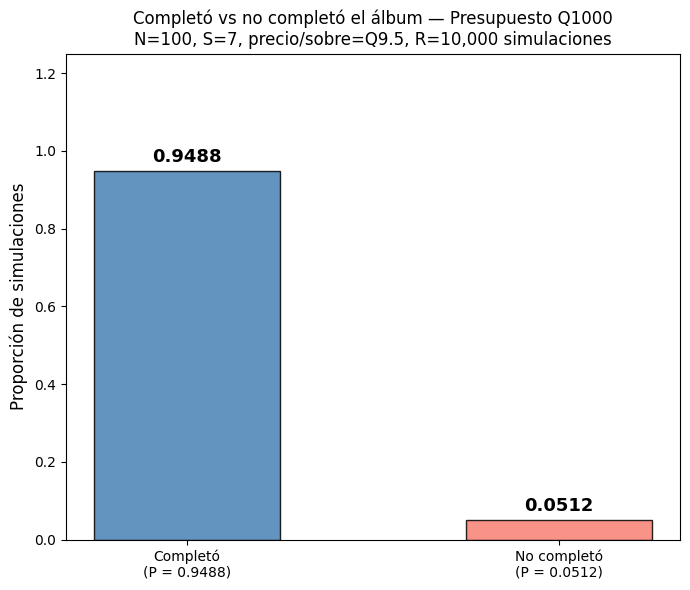

Gráfico guardado: proporcion_completar_budget.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 6))
proportions = [prob_complete, 1.0 - prob_complete]
labels = [
    f'Completó\n(P = {prob_complete:.4f})',
    f'No completó\n(P = {1 - prob_complete:.4f})',
]
bars = ax.bar(labels, proportions, color=['steelblue', 'salmon'],
              edgecolor='black', alpha=0.85, width=0.5)
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 0.012, f'{h:.4f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.25)
ax.set_ylabel('Proporción de simulaciones', fontsize=12)
ax.set_title(
    f'Completó vs no completó el álbum — Presupuesto Q{BUDGET:.0f}\n'
    f'N={N}, S={S}, precio/sobre=Q{PRICE}, R={R:,} simulaciones',
    fontsize=12
)
plt.tight_layout()
plt.savefig('proporcion_completar_budget.png', dpi=150)
plt.show()
print('Gráfico guardado: proporcion_completar_budget.png')

## Preguntas de Análisis — Etapa 3

A continuación se responden las tres preguntas de análisis propuestas.

### Pregunta 1
**¿El máximo de sobres que se pueden comprar con Q 1 000 alcanza el mínimo teórico sin estampas repetidas?**

El *mínimo teórico* es el número de sobres necesarios en el escenario ideal donde ninguna estampa se repite entre sobres:

$$\text{Mínimo teórico} = \left\lceil \frac{N}{S} \right\rceil = \left\lceil \frac{100}{7} \right\rceil = 15 \text{ sobres}$$

El máximo de sobres comprables con el presupuesto es:

$$\text{Máximo} = \left\lfloor \frac{Q\,1000}{Q\,9.50} \right\rfloor = \left\lfloor 105.26 \right\rfloor = 105 \text{ sobres}$$

In [5]:
theo_min  = math.ceil(N / S)      # = 15
max_packs = int(BUDGET // PRICE)  # = 105

print(f"Máximo de sobres comprables con Q{BUDGET:.0f}:  floor({BUDGET}/{PRICE}) = {max_packs}")
print(f"Mínimo teórico sin repetidos:           ceil({N}/{S})  = {theo_min}")
print()
if max_packs >= theo_min:
    print(f"Respuesta: SÍ  ({max_packs} >= {theo_min})")
    print(f"El presupuesto permite comprar {max_packs} sobres, {max_packs - theo_min} más que el mínimo teórico.")
    print(f"En la práctica el mínimo es inalcanzable: siempre hay repeticiones entre sobres.")
    print(f"La simulación lo confirma: media ~ {mean_packs_all:.0f} sobres para completar el álbum.")
else:
    print(f"Respuesta: NO  ({max_packs} < {theo_min})")
    print("El presupuesto es insuficiente incluso en el caso sin repeticiones.")

Máximo de sobres comprables con Q1000:  floor(1000.0/9.5) = 105
Mínimo teórico sin repetidos:           ceil(100/7)  = 15

Respuesta: SÍ  (105 >= 15)
El presupuesto permite comprar 105 sobres, 90 más que el mínimo teórico.
En la práctica el mínimo es inalcanzable: siempre hay repeticiones entre sobres.
La simulación lo confirma: media ~ 72 sobres para completar el álbum.


### Pregunta 2
**Simular la compra de una caja de 104 sobres (Q 975) y comparar su probabilidad con la de sobres sueltos.**

La caja tiene un precio unitario de $Q\,975 / 104 \approx Q\,9.375$ por sobre, más barato que el suelto ($Q\,9.50$).  
Con el mismo presupuesto de Q 975 en sueltos solo se obtienen $\lfloor 975/9.50 \rfloor = 102$ sobres.

| Modalidad | Sobres | Gasto |
|:---|:---:|:---:|
| Sueltos con Q 975 (mismo presupuesto que la caja) | 102 | Q 969.00 |
| Caja de 104 sobres | 104 | Q 975.00 |
| Sueltos con Q 1 000 (presupuesto completo) | 105 | Q 997.50 |

In [6]:
BOX_PACKS          = 104
BOX_PRICE          = 975.0
loose_with_box_bgt = int(BOX_PRICE // PRICE)        # 102
box_unit_price     = BOX_PRICE / BOX_PACKS          # 9.375 Q/sobre
savings_vs_loose   = BOX_PACKS * PRICE - BOX_PRICE  # Q 13.00

print('Simulando caja de 104 sobres...')
prob_box       = simulate_packs(BOX_PACKS,          seed=SEED)

print('Simulando sueltos con Q975 (102 sobres)...')
prob_loose_102 = simulate_packs(loose_with_box_bgt, seed=SEED)

print()
print(f"  Precio unitario — sobre suelto: Q{PRICE:.2f}")
print(f"  Precio unitario — caja:         Q{box_unit_price:.4f}  (ahorra Q{savings_vs_loose:.2f} vs 104 sueltos)")
print()
print(f"  {'Modalidad':<45} {'Sobres':>7}  {'Gasto':>9}  {'P(completar)':>13}")
print(f"  {'-'*45} {'-'*7}  {'-'*9}  {'-'*13}")
print(f"  {'Sueltos con Q975 (mismo presupuesto)':<45} {loose_with_box_bgt:>7}  {f'Q{loose_with_box_bgt * PRICE:.2f}':>9}  {prob_loose_102:>13.4f}")
print(f"  {'Caja de 104 sobres':<45} {BOX_PACKS:>7}  {f'Q{BOX_PRICE:.0f}':>9}  {prob_box:>13.4f}")
print(f"  {'Sueltos con Q1000 (presupuesto completo)':<45} {max_packs_possible:>7}  {f'Q{max_packs_possible * PRICE:.2f}':>9}  {prob_complete:>13.4f}")
print()
print(f"  Conclusión:")
print(f"  Con Q{BOX_PRICE:.0f}, la caja entrega {BOX_PACKS - loose_with_box_bgt} sobres más que sueltos ({BOX_PACKS} vs {loose_with_box_bgt}).")
print(f"  La caja supera a los sueltos equivalentes en: {prob_box - prob_loose_102:+.4f} ({(prob_box - prob_loose_102)*100:+.2f} p.p.)")

Simulando caja de 104 sobres...
Simulando sueltos con Q975 (102 sobres)...

  Precio unitario — sobre suelto: Q9.50
  Precio unitario — caja:         Q9.3750  (ahorra Q13.00 vs 104 sueltos)

  Modalidad                                      Sobres      Gasto   P(completar)
  --------------------------------------------- -------  ---------  -------------
  Sueltos con Q975 (mismo presupuesto)              102    Q969.00         0.9378
  Caja de 104 sobres                                104       Q975         0.9468
  Sueltos con Q1000 (presupuesto completo)          105    Q997.50         0.9488

  Conclusión:
  Con Q975, la caja entrega 2 sobres más que sueltos (104 vs 102).
  La caja supera a los sueltos equivalentes en: +0.0090 (+0.90 p.p.)


### Pregunta 3
**¿Qué estrategia mixta (caja + sueltos) maximiza $P(\text{completar})$ sin exceder Q 1 000?**

Con Q 1 000 de presupuesto, las opciones factibles son:

| Estrategia | Sobres | Gasto |
|:---|:---:|:---:|
| Solo sueltos | $\lfloor 1000/9.50 \rfloor = 105$ | Q 997.50 |
| Solo caja | 104 | Q 975.00 |
| **Caja + sueltos extra** | $104 + \lfloor(1000-975)/9.50\rfloor = 104 + 2 = \mathbf{106}$ | **Q 994.00** |

> La caja libera Q 13 de ahorro (vs 104 sueltos) más Q 2.50 de vuelto de la estrategia
> de sueltos puros, financiando **2 sobres extra** y llegando a **106 sobres** por Q 994.

In [7]:
extra_loose = int((BUDGET - BOX_PRICE) // PRICE)  # floor(25/9.50) = 2
mixed_total = BOX_PACKS + extra_loose             # 106
mixed_cost  = BOX_PRICE + extra_loose * PRICE     # Q 994.00

print('Simulando estrategia mixta (caja + 2 sueltos = 106 sobres)...')
prob_mixed = simulate_packs(mixed_total, seed=SEED)

print()
print(f"  {'Estrategia':<44} {'Sobres':>7}  {'Gasto':>9}  {'P(completar)':>13}")
print(f"  {'-'*44} {'-'*7}  {'-'*9}  {'-'*13}")
print(f"  {'Solo sueltos':<44} {max_packs_possible:>7}  {f'Q{max_packs_possible * PRICE:.2f}':>9}  {prob_complete:>13.4f}")
print(f"  {'Solo caja':<44} {BOX_PACKS:>7}  {f'Q{BOX_PRICE:.0f}':>9}  {prob_box:>13.4f}")
print(f"  {f'Caja + {extra_loose} sueltos  [OPTIMA]':<44} {mixed_total:>7}  {f'Q{mixed_cost:.2f}':>9}  {prob_mixed:>13.4f}")
print()
print(f"  >> MEJOR ESTRATEGIA: caja ({BOX_PACKS} sobres, Q{BOX_PRICE:.0f}) + {extra_loose} sueltos (Q{extra_loose * PRICE:.2f})")
print(f"     Total: {mixed_total} sobres por Q{mixed_cost:.2f}")
print(f"     P(completar) = {prob_mixed:.4f}  ({prob_mixed*100:.2f}%)")
print()
print(f"  Por qué es óptima:")
print(f"  - La caja a Q{box_unit_price:.4f}/sobre vs Q{PRICE:.2f}/suelto ahorra Q{savings_vs_loose:.2f} en {BOX_PACKS} sobres.")
print(f"  - Esos Q{savings_vs_loose:.2f} + Q{BUDGET - max_packs_possible * PRICE:.2f} de vuelto financian {extra_loose} sobres más.")
print(f"  - {mixed_total} sobres vs {max_packs_possible} (sueltos puros) -> 1 sobre más, mayor probabilidad.")
print()
print(f"  Ganancia vs solo sueltos: {prob_mixed - prob_complete:+.4f} ({(prob_mixed - prob_complete)*100:+.2f} p.p.)")
print(f"  Ganancia vs solo caja:    {prob_mixed - prob_box:+.4f} ({(prob_mixed - prob_box)*100:+.2f} p.p.)")
print(f"  Dinero ahorrado vs solo sueltos: Q{max_packs_possible * PRICE - mixed_cost:.2f}")

Simulando estrategia mixta (caja + 2 sueltos = 106 sobres)...

  Estrategia                                    Sobres      Gasto   P(completar)
  -------------------------------------------- -------  ---------  -------------
  Solo sueltos                                     105    Q997.50         0.9488
  Solo caja                                        104       Q975         0.9468
  Caja + 2 sueltos  [OPTIMA]                       106    Q994.00         0.9544

  >> MEJOR ESTRATEGIA: caja (104 sobres, Q975) + 2 sueltos (Q19.00)
     Total: 106 sobres por Q994.00
     P(completar) = 0.9544  (95.44%)

  Por qué es óptima:
  - La caja a Q9.3750/sobre vs Q9.50/suelto ahorra Q13.00 en 104 sobres.
  - Esos Q13.00 + Q2.50 de vuelto financian 2 sobres más.
  - 106 sobres vs 105 (sueltos puros) -> 1 sobre más, mayor probabilidad.

  Ganancia vs solo sueltos: +0.0056 (+0.56 p.p.)
  Ganancia vs solo caja:    +0.0076 (+0.76 p.p.)
  Dinero ahorrado vs solo sueltos: Q3.50


# Etapa 4: Efecto del intercambio de repetidas


ETAPA 4: EFECTO DEL INTERCAMBIO DE REPETIDAS

Parte A: Simulación hasta completar el álbum
-----------------------------------------------------------------
  Sin intercambio: Media = 72.25, Desv = 17.47
  K=1: Media = 15.00, Desv = 0.00 (Reducción: 79.24%)
  K=2: Media = 19.85, Desv = 0.54 (Reducción: 72.53%)
  K=5: Media = 28.11, Desv = 1.44 (Reducción: 61.09%)
  K=10: Media = 35.15, Desv = 2.45 (Reducción: 51.35%)


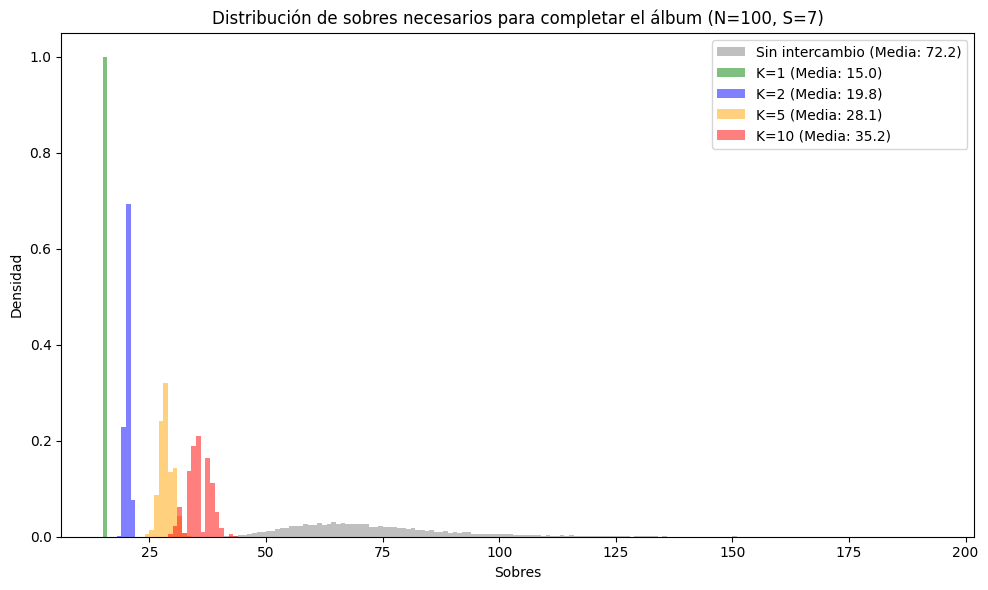

  [Gráfico guardado: hist_intercambio.png]

Parte B: Probabilidad de éxito en función de M sobres
-----------------------------------------------------------------
  Simulando para Sin intercambio...
  Simulando para K=1...
  Simulando para K=2...
  Simulando para K=5...
  Simulando para K=10...

  Sobres necesarios para alcanzar probabilidad:
  Config             | 50%   | 75%   | 90%  
  -------------------+-------+-------+------
  Sin intercambio    | 70    | >70   | >70  
  K=1                | 20    | 20    | 20   
  K=2                | 20    | 20    | 20   
  K=5                | 30    | 30    | 30   
  K=10               | 35    | 40    | 40   


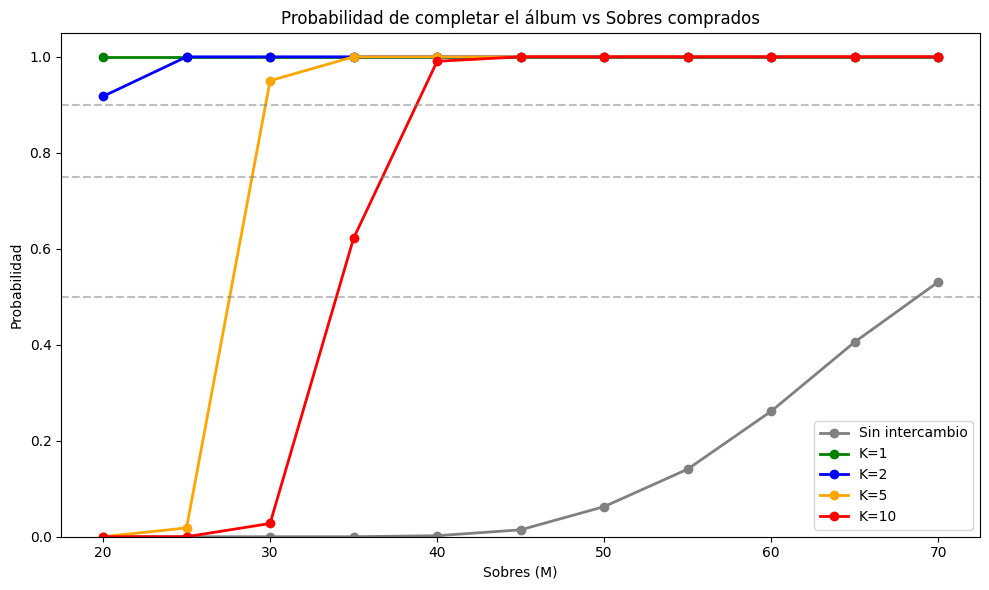


  [Gráfico guardado: prob_vs_M_intercambio.png]


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# ETAPA 4 — Efecto del intercambio de repetidas
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("ETAPA 4: EFECTO DEL INTERCAMBIO DE REPETIDAS")
print("=" * 65)

np.random.seed(SEED)
K_values = [None, 1, 2, 5, 10]
M_values_b = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]

def simulate_exchange_until_complete(K):
    """
    Simula la compra de sobres hasta completar el álbum, aplicando el canje
    de K estampas repetidas por 1 faltante (si K is not None).
    """
    collected = set()
    repeated_count = 0
    packs = 0
    
    while len(collected) < N:
        pack = np.random.choice(N, S, replace=False)
        packs += 1
        for sticker in pack:
            if sticker in collected:
                repeated_count += 1
            else:
                collected.add(sticker)
        
        # Proceso de canje al final del sobre
        if K is not None:
            while repeated_count >= K and len(collected) < N:
                repeated_count -= K
                missing = list(set(range(N)) - collected)
                if missing:
                    new_sticker = np.random.choice(missing)
                    collected.add(new_sticker)
                    
    return packs

def simulate_exchange_fixed_packs(K, fixed_M):
    """
    Simula la compra de un número exacto de sobres, aplicando el canje
    de K estampas repetidas por 1 faltante (si K is not None).
    Devuelve True si completa el álbum, False en caso contrario.
    """
    collected = set()
    repeated_count = 0
    
    for _ in range(fixed_M):
        pack = np.random.choice(N, S, replace=False)
        for sticker in pack:
            if sticker in collected:
                repeated_count += 1
            else:
                collected.add(sticker)
                
        if K is not None:
            while repeated_count >= K and len(collected) < N:
                repeated_count -= K
                missing = list(set(range(N)) - collected)
                if missing:
                    new_sticker = np.random.choice(missing)
                    collected.add(new_sticker)
                    
        if len(collected) == N:
            return True
            
    return len(collected) == N

# ── Parte A: Simulación hasta completar ───────────────────────────────────────
print("\nParte A: Simulación hasta completar el álbum")
print("-" * 65)

results_A = {}
mean_no_exchange = None

for K in K_values:
    np.random.seed(SEED) # Reset para comparar con la misma secuencia base
    packs_needed = [simulate_exchange_until_complete(K) for _ in range(R)]
    mean_p = np.mean(packs_needed)
    std_p = np.std(packs_needed)
    
    if K is None:
        mean_no_exchange = mean_p
        results_A['Sin intercambio'] = packs_needed
        print(f"  Sin intercambio: Media = {mean_p:.2f}, Desv = {std_p:.2f}")
    else:
        reduction = (1 - (mean_p / mean_no_exchange)) * 100
        results_A[f'K={K}'] = packs_needed
        print(f"  K={K}: Media = {mean_p:.2f}, Desv = {std_p:.2f} (Reducción: {reduction:.2f}%)")

# Visualización Parte A
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['gray', 'green', 'blue', 'orange', 'red']
for (label, data), color in zip(results_A.items(), colors):
    ax.hist(data, bins=range(min(data), max(data)+2), alpha=0.5, label=f'{label} (Media: {np.mean(data):.1f})', color=color, density=True)
ax.set_title(f'Distribución de sobres necesarios para completar el álbum (N={N}, S={S})')
ax.set_xlabel('Sobres')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.savefig('hist_intercambio.png', dpi=150)
plt.show()
print("  [Gráfico guardado: hist_intercambio.png]")

# ── Parte B: Probabilidad de éxito en función de M ────────────────────────────
print("\nParte B: Probabilidad de éxito en función de M sobres")
print("-" * 65)

results_B = {K: [] for K in K_values}

for K in K_values:
    print(f"  Simulando para {'Sin intercambio' if K is None else f'K={K}'}...")
    for M in M_values_b:
        np.random.seed(SEED + M) # Asegurar variabilidad entre Ms
        successes = sum(simulate_exchange_fixed_packs(K, M) for _ in range(R))
        prob = successes / R
        results_B[K].append(prob)

def find_M_for_prob(probs, M_vals, target):
    for m, p in zip(M_vals, probs):
        if p >= target:
            return m
    return ">" + str(max(M_vals))

print("\n  Sobres necesarios para alcanzar probabilidad:")
print(f"  {'Config':<18} | {'50%':<5} | {'75%':<5} | {'90%':<5}")
print(f"  {'-'*18}-+-{'-'*5}-+-{'-'*5}-+-{'-'*5}")
for K in K_values:
    label = 'Sin intercambio' if K is None else f'K={K}'
    probs = results_B[K]
    m50 = find_M_for_prob(probs, M_values_b, 0.50)
    m75 = find_M_for_prob(probs, M_values_b, 0.75)
    m90 = find_M_for_prob(probs, M_values_b, 0.90)
    print(f"  {label:<18} | {str(m50):<5} | {str(m75):<5} | {str(m90):<5}")

# Visualización Parte B
fig, ax = plt.subplots(figsize=(10, 6))
for (K, probs), color in zip(results_B.items(), colors):
    label = 'Sin intercambio' if K is None else f'K={K}'
    ax.plot(M_values_b, probs, marker='o', color=color, label=label, linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0.75, color='gray', linestyle='--', alpha=0.5)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Probabilidad de completar el álbum vs Sobres comprados')
ax.set_xlabel('Sobres (M)')
ax.set_ylabel('Probabilidad')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig('prob_vs_M_intercambio.png', dpi=150)
plt.show()
print("\n  [Gráfico guardado: prob_vs_M_intercambio.png]")


# Preguntas de Análisis

In [9]:

# 1. 
print("\nPregunta 1: ¿Cómo afecta la disminución de K al número esperado de sobres y a la probabilidad de éxito? ¿Es lineal la relación?")
print("-" * 65)
print("Respuesta:")
print("La disminución de K (es decir, una tasa de intercambio más favorable) reduce drásticamente el número medio")
print("de sobres necesarios y desplaza la curva de probabilidad hacia la izquierda (se alcanza el éxito con menos sobres).")
print("La relación NO es lineal. Como se observa en la reducción porcentual (Parte A), pasar de Sin Intercambio a K=10")
print("produce un ahorro moderado, pero los saltos de K=10 a K=5, y sobre todo a K=2 y K=1, presentan mejoras mucho")
print("más aceleradas, mostrando rendimientos decrecientes cuando K es alto, y ganancias masivas cuando K se acerca a 1.")

# 2.
print("\nPregunta 2: Para K = 2, ¿cuántos sobres se ahorran en promedio respecto al caso sin intercambio? Exprese en Q.")
print("-" * 65)
ahorro_sobres_K2 = np.mean(results_A['Sin intercambio']) - np.mean(results_A['K=2'])
ahorro_quetzales_K2 = ahorro_sobres_K2 * PRICE
print("Respuesta:")
print(f"Sobres ahorrados en promedio: {ahorro_sobres_K2:.2f} sobres.")
print(f"Ahorro monetario (a Q{PRICE} por sobre): Q{ahorro_quetzales_K2:.2f}")

# 3.
print("\nPregunta 3: Para M=45, ¿cuánto aumenta la probabilidad al pasar de K=10 a K=5, y de K=5 a K=1?")
print("-" * 65)
idx_45 = M_values_b.index(45)
prob_k10_45 = results_B[10][idx_45]
prob_k5_45 = results_B[5][idx_45]
prob_k1_45 = results_B[1][idx_45]
print("Respuesta:")
print(f"Aumento de K=10 (P={prob_k10_45:.4f}) a K=5 (P={prob_k5_45:.4f}): +{prob_k5_45 - prob_k10_45:.4f} ({(prob_k5_45 - prob_k10_45)*100:.2f}%)")
print(f"Aumento de K=5 (P={prob_k5_45:.4f}) a K=1 (P={prob_k1_45:.4f}): +{prob_k1_45 - prob_k5_45:.4f} ({(prob_k1_45 - prob_k5_45)*100:.2f}%)")

# 4.
print("\nPregunta 4: ¿Existe un valor de K a partir del cual mejorar la tasa produce muy poco beneficio adicional?")
print("-" * 65)
print("Respuesta:")
print("Sí. Observando los resultados, los valores de K más altos (por ejemplo, K mayores a 10) ofrecen beneficios")
print("marginales muy reducidos en comparación con valores cercanos a 1. La razón es que con una tasa de cambio")
print("exigente, necesitas acumular demasiadas repetidas para conseguir 1 faltante. Como el número total de")
print("figuritas que coleccionas es pequeño comparado con ese umbral, la mayoría de las figuritas repetidas")
print("nunca se llegan a canjear y el efecto sobre la distribución se diluye fuertemente.")

# 5.
print("\nPregunta 5: Costo efectivo por estampa nueva obtenida mediante canje y tasa más rentable.")
print("-" * 65)
print("Respuesta:")
print("Las estampas repetidas provienen de sobres ya pagados. Si consideramos los sobres como un 'costo hundido',")
print("el costo efectivo adicional del canje es Q0.00. Sin embargo, en términos de 'costo de oportunidad',")
print("para obtener 1 estampa nueva se requirieron K repetidas, que vinieron de sobres cuyo costo es Q9.50/7 = Q1.36 c/u.")
print("Por lo tanto, la inversión indirecta por cada estampa canjeada es de K * (9.50 / 7) Quetzales.")
print(f"Para K=2: 2 * 1.36 = Q2.71. Para K=10: 10 * 1.36 = Q13.57.")
print("Si se pudiera elegir, la tasa más rentable es K=1, ya que transforma cada repetida inútil directamente")
print("en una estampa útil con un costo de oportunidad mínimo.")


Pregunta 1: ¿Cómo afecta la disminución de K al número esperado de sobres y a la probabilidad de éxito? ¿Es lineal la relación?
-----------------------------------------------------------------
Respuesta:
La disminución de K (es decir, una tasa de intercambio más favorable) reduce drásticamente el número medio
de sobres necesarios y desplaza la curva de probabilidad hacia la izquierda (se alcanza el éxito con menos sobres).
La relación NO es lineal. Como se observa en la reducción porcentual (Parte A), pasar de Sin Intercambio a K=10
produce un ahorro moderado, pero los saltos de K=10 a K=5, y sobre todo a K=2 y K=1, presentan mejoras mucho
más aceleradas, mostrando rendimientos decrecientes cuando K es alto, y ganancias masivas cuando K se acerca a 1.

Pregunta 2: Para K = 2, ¿cuántos sobres se ahorran en promedio respecto al caso sin intercambio? Exprese en Q.
-----------------------------------------------------------------
Respuesta:
Sobres ahorrados en promedio: 52.40 sobres.
Aho